### Plots for the poster 
### N400 and P600 plot for the introduction of the report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the four datasets on the cluster

In [2]:
adbc_path = "/home/meganorm-mene/project_mene/P6Datasets/adbc23/adbc23_data/adbc23_erp.csv"
adbc_df = pd.read_csv(adbc_path)

cody_path = "/home/meganorm-mene/project_mene/P6Datasets/cody23/dbc19_data.csv"
cody_df2 = pd.read_csv(cody_path)

imer_path = "/home/meganorm-mene/project_mene/P6Datasets/imer21/CAPExp.csv"
imer_df = pd.read_csv(imer_path)

osf_path = "/home/meganorm-mene/project_mene/P6Datasets/osf_archive/data/dbac25.csv"
osf_df = pd.read_csv(osf_path)

electrodes = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']

### Plot of the N400 and P600 effects for the thesis introduction using one dataset and the Pz electrode

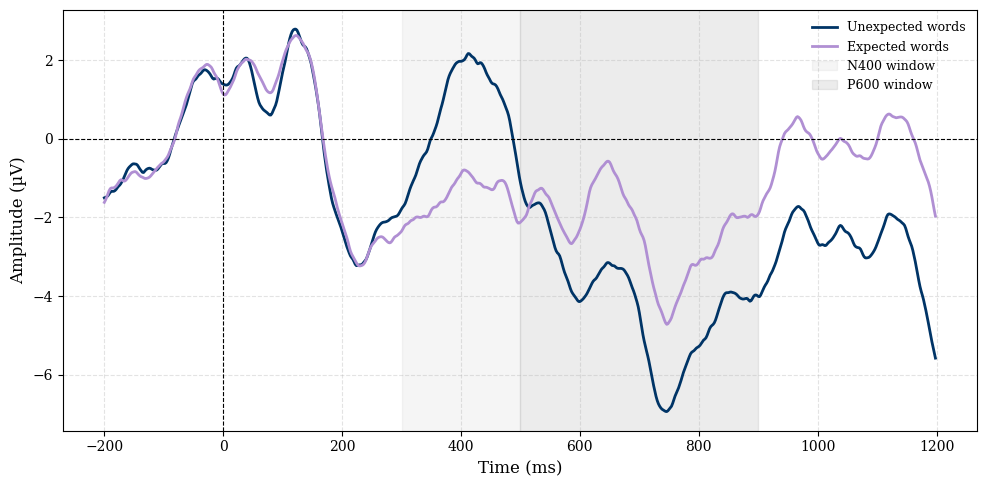

In [ ]:
# thesis style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9  
})

df = imer_df.copy() # choose one dataset to show the N400 and P600 in the introduction
df["Cloze_group"] = None
df.loc[df["Cloze"] == 0, "Cloze_group"] = "Low" # if cloze=0 -> low expectancy
df.loc[df["Cloze"] > 0, "Cloze_group"] = "High" # if cloze>0, high expectancy
df = df.dropna(subset=["Cloze_group"])
df = df[df["Timestamp"] <= 1200] # plot until 1,200 ms

# compute grand average per condition at Pz
grand_avg = (df.groupby(["Cloze_group", "Timestamp"])["Pz"].mean().reset_index())

label_map = {
    "Low": "Unexpected words",
    "High": "Expected words"
}

# plot
plt.figure(figsize=(10, 5))

# plot the two ERP lines
for group, color in zip(["Low", "High"], ["#003466", "#B08FD3"]):
    data = grand_avg[grand_avg["Cloze_group"] == group]
    plt.plot(data["Timestamp"], -data["Pz"], linewidth=2, color=color, label=label_map[group])

plt.axhline(0, color="black", linewidth=0.8, linestyle="--") # plot the line where the epoch starts

# color out the N400 and P600 windows
plt.axvspan(300, 500, alpha=0.08, color="gray", label="N400 window")
plt.axvspan(500, 900, alpha=0.15, color="gray", label="P600 window")

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.legend(frameon=False, loc="upper right")  # add the legend
plt.grid(True, linestyle="--", alpha=0.35) # add grid
plt.tight_layout()
plt.savefig("erp_pz_thesis.pdf", bbox_inches="tight")
plt.show()

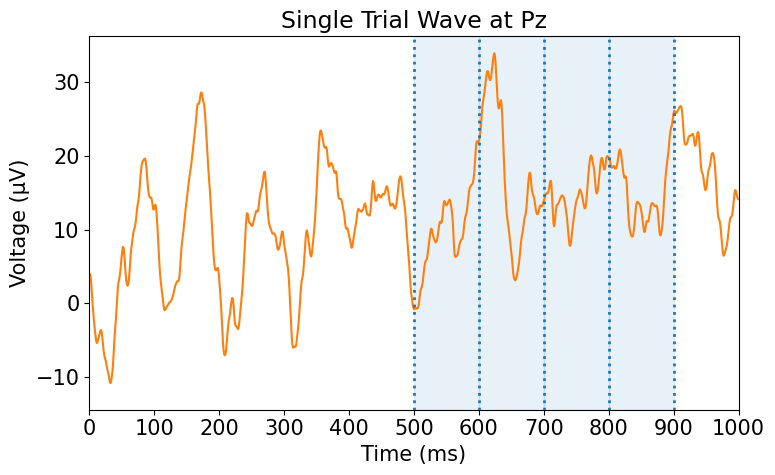

In [ ]:
# plot one random trial to show the binning procedure
trial_df = adbc_df[adbc_df["Trial"] == 4]
electrode = "Pz"

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "legend.fontsize": 13,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15
})

plt.figure(figsize=(8,5))

# Plot ERP waveform
plt.plot(trial_df["Timestamp"], trial_df[electrode], linewidth=1.5, color="tab:orange")

# Bins
bins = [500, 600, 700, 800, 900]

# Shade bins
for i in range(len(bins)-1):
    plt.axvspan(bins[i], bins[i+1], color="tab:blue", alpha=0.1)

# Draw vertical dotted lines
for b in bins:
    plt.axvline(x=b, linestyle=":", linewidth=2, color="tab:blue")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (µV)")
plt.title(f"Single Trial Wave at Pz")

plt.xlim(0, 1000)
plt.xticks(range(0, 1001, 100))

plt.tight_layout()
plt.savefig("single_trial.svg", bbox_inches="tight")
plt.show()